# Morph2REP Wavelet Estrous Aberration Pipeline  
## Auto-QC Thresholding + Per-Replicate PCA + Gaussian Mixture + Monte Carlo

This notebook is the “full pipeline” version you asked for:

### Goals
1) **Automatically quality-control (QC)** animal-days using a **data-driven threshold**, so Rep/Dose groups don’t need the same cutoff.  
2) Build wavelet-only daily features and run analysis **per replicate** (and optionally per dose group).  
3) Produce:
- **PCA** (explained variance + loadings)  
- **Gaussian Mixture Model (GMM)** “aberrant state probability”  
- **Handling confound enrichment** (event±1 vs normal)  
- **Monte Carlo null test** for ~4-day cyclicity in `p_aberrant`  

### Important note on “ideal threshold”
There is no perfect “true” threshold without ground truth labels. What we can do robustly is:
- **Detect recording/tracking failures** using `minutes_with_any_bout` (better than locomotion for dose groups).
- Choose thresholds by **separating a low-coverage mode from a normal-coverage mode** using a mixture model (GMM + BIC).
- Provide sensitivity checks and report how many days were removed.

This notebook uses `minutes_with_any_bout` as the QC anchor by default, and can also apply a **relative per-animal coverage ratio** filter.

In [4]:

# =============================================================================
# 0) Imports
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import duckdb
from datetime import datetime

from scipy.signal import cwt, morlet2
from scipy.stats import mannwhitneyu

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 10

print("Imports ready.")

Imports ready.


---
## 1) Configuration

### You can run:
- **Vehicle only** (default config below), OR
- multiple dose groups by adding cage IDs to `GROUPS`.

Each group has `Rep1` and `Rep2` entries with:
- cage IDs
- date range
- valid day range (exclude partial day 1)
- event timestamps (dose 1, cage change, dose 2)

**If you add dose cages**, keep the correct dates/events for those replicates.

In [5]:

# =============================================================================
# Constants + wavelet periods
# =============================================================================
MINUTES_PER_DAY = 1440
PERIODS_MINUTES = np.logspace(np.log10(60), np.log10(39 * 60), 50)  # 1h..39h
S3_BASE = "s3://jax-envision-public-data/study_1001/2025v3.3/tabular"
COV_COLS  = ["animal_id", "start_time", "end_time"]                 # any bout coverage
LOCO_COLS = ["animal_id", "start_time", "end_time", "state_name"]   # locomotion filter needs state_name
# =============================================================================
# GROUP CONFIG
# Fill dose cages later if you want (dose5, dose25).
# The pipeline loops: for group in GROUPS, for rep in Rep1/Rep2.
# =============================================================================
GROUPS = {
    "vehicle": {
        "Rep1": {
            "cages": [4918, 4922, 4923],
            "analysis_start": "2025-01-07",
            "analysis_end": "2025-01-22",
            "n_days": 16,
            "valid_days": (2, 16),
            "dose_1": datetime(2025, 1, 14, 6, 0),
            "dose_2": datetime(2025, 1, 17, 17, 0),
            "cage_change": datetime(2025, 1, 15, 12, 0),
        },
        "Rep2": {
            "cages": [4928, 4929, 4934],
            "analysis_start": "2025-01-22",
            "analysis_end": "2025-02-04",
            "n_days": 14,
            "valid_days": (2, 14),
            "dose_1": datetime(2025, 1, 28, 17, 0),
            "dose_2": datetime(2025, 1, 31, 6, 0),
            "cage_change": datetime(2025, 1, 29, 12, 0),
        },
    },

    # TEMPLATE (optional)
    # "dose5": {...},
    # "dose25": {...},
}

# Pre-compute event day numbers (calendar days)
for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        start = pd.to_datetime(cfg["analysis_start"]).date()
        cfg["dose_1_day"] = (cfg["dose_1"].date() - start).days + 1
        cfg["dose_2_day"] = (cfg["dose_2"].date() - start).days + 1
        cfg["cage_change_day"] = (cfg["cage_change"].date() - start).days + 1

print("Configured groups:", list(GROUPS.keys()))
for g in GROUPS:
    for rep in ["Rep1","Rep2"]:
        cfg = GROUPS[g][rep]
        print(g, rep, "event days:", {"dose_1": cfg["dose_1_day"], "cage_change": cfg["cage_change_day"], "dose_2": cfg["dose_2_day"]})

Configured groups: ['vehicle']
vehicle Rep1 event days: {'dose_1': 8, 'cage_change': 9, 'dose_2': 11}
vehicle Rep2 event days: {'dose_1': 7, 'cage_change': 8, 'dose_2': 10}


---
## 2) S3 Loading Helpers (DuckDB)

We load `animal_bouts.parquet` from S3 for each cage/day.  
We keep the raw bouts because we need:
- coverage from **any** bout state (`minutes_with_any_bout`)
- wavelet signal from **locomotion** bouts only

In [6]:
def make_duckdb_conn():
    conn = duckdb.connect()
    conn.execute("INSTALL httpfs; LOAD httpfs;")
    conn.execute("SET s3_region='us-east-1';")
    return conn

def load_parquet_s3(conn, cage_id, start_date, end_date, table_name,
                    columns=None, where=None):
    """
    Memory-safe loader:
      - reuses a DuckDB connection
      - reads only selected columns
      - supports WHERE filtering (e.g., locomotion only)
    """
    dates = pd.date_range(start_date, end_date, freq="D")
    out = []

    cols_sql = "*" if (not columns) else ", ".join(columns)
    where_sql = "" if (not where) else f" WHERE {where}"

    for d in dates:
        date_str = d.strftime("%Y-%m-%d")
        path = f"{S3_BASE}/cage_id={cage_id}/date={date_str}/{table_name}"
        try:
            df = conn.execute(
                f"SELECT {cols_sql} FROM read_parquet('{path}'){where_sql}"
            ).fetchdf()
            if df.empty:
                continue
            df["cage_id"] = cage_id
            df["date"] = date_str
            out.append(df)
        except Exception:
            continue

    return pd.concat(out, ignore_index=True) if out else pd.DataFrame()

def _ensure_end_time(df: pd.DataFrame) -> pd.DataFrame:
    """
    Ensure df has an 'end_time' column.
    Accepts any of: end_time, stop_time, end_ts, end_datetime.
    Or constructs end_time from duration_seconds / duration_ms / duration_min / duration_minutes.
    """
    df = df.copy()

    # 1) Use an existing end column if available
    for cand in ["end_time", "stop_time", "end_ts", "end_datetime"]:
        if cand in df.columns:
            df["end_time"] = pd.to_datetime(df[cand])
            break

    # 2) Otherwise build from duration
    if "end_time" not in df.columns or df["end_time"].isna().all():
        if "duration_seconds" in df.columns:
            df["end_time"] = pd.to_datetime(df["start_time"]) + pd.to_timedelta(df["duration_seconds"], unit="s")
        elif "duration_ms" in df.columns:
            df["end_time"] = pd.to_datetime(df["start_time"]) + pd.to_timedelta(df["duration_ms"], unit="ms")
        elif "duration_min" in df.columns:
            df["end_time"] = pd.to_datetime(df["start_time"]) + pd.to_timedelta(df["duration_min"], unit="m")
        elif "duration_minutes" in df.columns:
            df["end_time"] = pd.to_datetime(df["start_time"]) + pd.to_timedelta(df["duration_minutes"], unit="m")
        else:
            raise ValueError(
                "Need bout end times. Provide an end_time-like column (end_time/stop_time/...) "
                "or a duration column (duration_seconds/duration_ms/duration_min/duration_minutes)."
            )

    # Normalize start_time too
    df["start_time"] = pd.to_datetime(df["start_time"])
    return df


def compute_minutes_with_any_bout(df_bouts_rep, analysis_start, n_days, anchor_hour=0):
    start_time = pd.to_datetime(f"{analysis_start} {anchor_hour:02d}:00:00")
    n_minutes = int(n_days * MINUTES_PER_DAY)
    end_time = start_time + pd.Timedelta(minutes=n_minutes)

    df = _ensure_end_time(df_bouts_rep)
    df = df[(df["end_time"] > start_time) & (df["start_time"] < end_time)].copy()
    if df.empty:
        return pd.DataFrame(columns=["animal_id","day","minutes_with_any_bout"])

    s = (df["start_time"].clip(lower=start_time) - start_time).dt.total_seconds().to_numpy() / 60.0
    e = (df["end_time"].clip(upper=end_time)   - start_time).dt.total_seconds().to_numpy() / 60.0

    start_bin = np.clip(np.floor(s).astype(np.int32), 0, n_minutes)
    end_bin   = np.clip(np.ceil(e).astype(np.int32),  0, n_minutes)

    valid = end_bin > start_bin
    if not np.any(valid):
        return pd.DataFrame(columns=["animal_id","day","minutes_with_any_bout"])

    df2 = pd.DataFrame({
        "animal_id": df.loc[valid, "animal_id"].astype(int).to_numpy(),
        "start_bin": start_bin[valid],
        "end_bin": end_bin[valid],
    })

    # Split intervals across day boundaries (day-local bins [0,1440))
    pieces = []
    for aid, g in df2.groupby("animal_id", sort=False):
        for s0, e0 in g[["start_bin","end_bin"]].to_numpy():
            d_start = int(s0) // MINUTES_PER_DAY + 1
            d_end   = (int(e0) - 1) // MINUTES_PER_DAY + 1
            for day in range(d_start, d_end + 1):
                day0 = (day - 1) * MINUTES_PER_DAY
                ls = max(int(s0), day0) - day0
                le = min(int(e0), day0 + MINUTES_PER_DAY) - day0
                if le > ls:
                    pieces.append((int(aid), int(day), int(ls), int(le)))

    if not pieces:
        return pd.DataFrame(columns=["animal_id","day","minutes_with_any_bout"])

    tmp = pd.DataFrame(pieces, columns=["animal_id","day","ls","le"])

    # Union length per (animal_id, day)
    results = []
    for (aid, day), gg in tmp.groupby(["animal_id","day"], sort=False):
        intervals = gg[["ls","le"]].to_numpy()
        intervals = intervals[np.argsort(intervals[:, 0])]
        covered = 0
        cur_s, cur_e = intervals[0]
        for s2, e2 in intervals[1:]:
            if s2 <= cur_e:
                cur_e = max(cur_e, e2)
            else:
                covered += (cur_e - cur_s)
                cur_s, cur_e = s2, e2
        covered += (cur_e - cur_s)
        results.append((int(aid), int(day), int(covered)))

    return pd.DataFrame(results, columns=["animal_id","day","minutes_with_any_bout"])


def bouts_to_minute_counts_calendar(loco_bouts_df: pd.DataFrame, analysis_start: str, n_days: int, anchor_hour: int = 0, binary: bool = True) -> np.ndarray:
    """
    Locomotion bouts -> per-minute occupancy (or counts of overlapping bouts) across the whole window.
    Uses a difference array: diff[start]+=1, diff[end]-=1, then cumsum.

    binary=True => output is 0/1 for "locomotion present this minute"
    binary=False => output is integer count of overlapping locomotion bouts in that minute
    """
    start_time = pd.to_datetime(f"{analysis_start} {anchor_hour:02d}:00:00")
    n_minutes = int(n_days * MINUTES_PER_DAY)
    end_time = start_time + pd.Timedelta(minutes=n_minutes)

    df = _ensure_end_time(loco_bouts_df)

    df = df[(df["end_time"] > start_time) & (df["start_time"] < end_time)].copy()
    if df.empty:
        return np.zeros(n_minutes, dtype=float)

    s = (df["start_time"].clip(lower=start_time) - start_time).dt.total_seconds().to_numpy() / 60.0
    e = (df["end_time"].clip(upper=end_time)   - start_time).dt.total_seconds().to_numpy() / 60.0

    start_bin = np.floor(s).astype(np.int32)
    end_bin   = np.ceil(e).astype(np.int32)  # exclusive
    start_bin = np.clip(start_bin, 0, n_minutes)
    end_bin   = np.clip(end_bin,   0, n_minutes)

    valid = end_bin > start_bin
    if not np.any(valid):
        return np.zeros(n_minutes, dtype=float)

    start_bin = start_bin[valid]
    end_bin   = end_bin[valid]

    diff = np.zeros(n_minutes + 1, dtype=np.int32)
    np.add.at(diff, start_bin, 1)
    np.add.at(diff, end_bin, -1)

    occ = np.cumsum(diff[:-1])  # length n_minutes
    if binary:
        occ = (occ > 0).astype(np.float32)
    else:
        occ = occ.astype(np.float32)
    return occ


print("Helpers ready.")

Helpers ready.


---
## 3) Load Bouts for All Configured Groups

We load all cages for each (group, replicate), attach `group` and `replicate`, and parse timestamps.

In [7]:

# print("Loading bouts from S3...")

# all_bouts = []
# for group, reps in GROUPS.items():
#     for rep, cfg in reps.items():
#         for cage_id in cfg["cages"]:
#             df = load_parquet_s3(cage_id, cfg["analysis_start"], cfg["analysis_end"], "animal_bouts.parquet")
#             if len(df) == 0:
#                 continue
#             df["group"] = group
#             df["replicate"] = rep
#             all_bouts.append(df)

# df_bouts = pd.concat(all_bouts, ignore_index=True)
# df_bouts["start_time"] = pd.to_datetime(df_bouts["start_time"])
# df_bouts = df_bouts[df_bouts["animal_id"] != 0].copy()

# print("Total bouts:", len(df_bouts))
# print(df_bouts[["group","replicate","animal_id"]].drop_duplicates().groupby(["group","replicate"]).size())

In [8]:
conn = make_duckdb_conn()

cov_all = []

for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        vstart, vend = cfg["valid_days"]

        for cage_id in cfg["cages"]:
            df_cov = load_parquet_s3(
                conn,
                cage_id,
                cfg["analysis_start"],
                cfg["analysis_end"],
                "animal_bouts.parquet",
                columns=COV_COLS,
                where=None
            )
            if df_cov.empty:
                continue

            cov = compute_minutes_with_any_bout(df_cov, cfg["analysis_start"], cfg["n_days"], anchor_hour=0)
            cov["group"] = group
            cov["replicate"] = rep
            cov["cage_id"] = cage_id

            cov = cov[(cov["day"] >= vstart) & (cov["day"] <= vend)].copy()
            cov_all.append(cov)

cov_df = pd.concat(cov_all, ignore_index=True) if cov_all else pd.DataFrame()
print("Coverage rows (valid days):", len(cov_df))

Coverage rows (valid days): 332


In [9]:
# coverage_ratio must exist before qc rules / qc_keep
med = cov_df.groupby(["group","replicate","animal_id"])["minutes_with_any_bout"].transform("median")
cov_df["coverage_ratio"] = (cov_df["minutes_with_any_bout"] / med).replace([np.inf, -np.inf], np.nan).fillna(0.0)

---
## 4) Auto-QC Threshold Selection (Data-driven)

### What we are thresholding
We use `minutes_with_any_bout` as the primary QC variable because it is closer to **recording/tracking presence**, and won’t drop purely due to sedation.

### How we choose a threshold automatically
For each (group, replicate):
1. Compute `minutes_with_any_bout` per animal-day on valid days.
2. Fit **1-component vs 2-component Gaussian mixture** on `log1p(minutes_with_any_bout)`.
3. If the 2-component model is meaningfully better (lower BIC), treat the lower-mean component as “bad coverage” and set the threshold at the **posterior=0.5 boundary**.
4. If not, fall back to a conservative **low quantile** cutoff (e.g., 1st percentile), with a minimum of 1 minute to remove zeros.

### Optional: relative coverage ratio
Sometimes a single absolute cutoff isn’t enough. We also compute:
- `coverage_ratio = minutes_with_any_bout / median(minutes_with_any_bout per animal)`
and optionally threshold that too (also via GMM on `log(coverage_ratio)`).

In [10]:

def gmm_boundary_threshold(x_log, gmm):
    """Find log-space threshold where posterior(comp_low) = posterior(comp_high) by scanning."""
    means = gmm.means_.flatten()
    lo_idx = int(np.argmin(means))
    hi_idx = 1 - lo_idx

    grid = np.linspace(np.min(x_log), np.max(x_log), 2000).reshape(-1, 1)
    post = gmm.predict_proba(grid)
    diff = post[:, lo_idx] - post[:, hi_idx]
    # find sign change nearest 0
    k = np.argmin(np.abs(diff))
    return float(grid[k, 0]), lo_idx


def auto_threshold_minutes(minutes, bic_delta=10.0, fallback_q=0.01, min_minutes=1):
    """Automatic threshold on minutes_with_any_bout using 1 vs 2-component GMM on log1p."""
    m = np.asarray(minutes, dtype=float)
    m = m[np.isfinite(m)]
    if len(m) < 30:
        return max(min_minutes, float(np.quantile(m, fallback_q))), {"method": "quantile_smallN", "n": len(m)}

    x = np.log1p(m).reshape(-1, 1)

    g1 = GaussianMixture(n_components=1, random_state=0).fit(x)
    g2 = GaussianMixture(n_components=2, random_state=0).fit(x)

    bic1 = g1.bic(x)
    bic2 = g2.bic(x)

    info = {"bic1": float(bic1), "bic2": float(bic2), "bic_delta": float(bic1 - bic2), "n": int(len(m))}

    if (bic1 - bic2) > bic_delta:
        thr_log, lo_idx = gmm_boundary_threshold(x.flatten(), g2)
        thr = float(np.expm1(thr_log))
        return max(min_minutes, thr), {**info, "method": "gmm2", "low_comp": int(lo_idx), "thr_log": float(thr_log)}
    else:
        thr = float(np.quantile(m, fallback_q))
        return max(min_minutes, thr), {**info, "method": "quantile_fallback", "q": float(fallback_q)}


def auto_threshold_ratio(ratios, bic_delta=10.0, fallback=0.3, min_ratio=0.05, max_ratio=0.95):
    """Automatic threshold on coverage_ratio via GMM on log(ratio+eps)."""
    r = np.asarray(ratios, dtype=float)
    r = r[np.isfinite(r)]
    r = r[(r > 0) & (r < 10)]
    if len(r) < 30:
        return float(np.clip(fallback, min_ratio, max_ratio)), {"method": "fallback_smallN", "n": len(r)}

    x = np.log(r + 1e-8).reshape(-1, 1)
    g1 = GaussianMixture(n_components=1, random_state=0).fit(x)
    g2 = GaussianMixture(n_components=2, random_state=0).fit(x)
    bic1, bic2 = g1.bic(x), g2.bic(x)
    info = {"bic1": float(bic1), "bic2": float(bic2), "bic_delta": float(bic1 - bic2), "n": int(len(r))}

    if (bic1 - bic2) > bic_delta:
        thr_log, lo_idx = gmm_boundary_threshold(x.flatten(), g2)
        thr = float(np.exp(thr_log))
        return float(np.clip(thr, min_ratio, max_ratio)), {**info, "method": "gmm2", "thr_log": float(thr_log), "low_comp": int(lo_idx)}
    else:
        return float(np.clip(fallback, min_ratio, max_ratio)), {**info, "method": "fallback_fixed", "fallback": float(fallback)}


print("Auto-threshold functions ready.")

Auto-threshold functions ready.


In [23]:
# -----------------------------
# Conservative QC rule builder
# -----------------------------
MINUTES_FLOOR = 60     # remove near-empty days (recording failures)
MINUTES_CAP   = 1000   # prevent crazy high thresholds like 1369
RATIO_FLOOR   = 0.30   # forgiving; catches only animal-specific failures

qc_rules = []
for (group, rep), g in cov_df.groupby(["group","replicate"]):
    # 1) minutes threshold: use auto, but CLAMP to a conservative range
    thr_minutes_auto, info_m = auto_threshold_minutes(
        g["minutes_with_any_bout"].values,
        bic_delta=10.0,
        fallback_q=0.01,
        min_minutes=1,
    )
    thr_minutes = float(np.clip(thr_minutes_auto, MINUTES_FLOOR, MINUTES_CAP))

    # 2) ratio threshold: FIXED conservative (do NOT auto-threshold; it over-tightens)
    thr_ratio = float(RATIO_FLOOR)
    info_r = {"method": "fixed_conservative", "thr_ratio": thr_ratio}

    qc_rules.append({
        "group": group,
        "replicate": rep,
        "thr_minutes_any": thr_minutes,
        "thr_ratio": thr_ratio,
        "info_minutes": info_m,
        "info_ratio": info_r,
        "n_rows": int(len(g)),
    })

qc_rules_df = pd.DataFrame(qc_rules)
qc_rules_df

,group,replicate,thr_minutes_any,thr_ratio,info_minutes,info_ratio,n_rows
0,vehicle,Rep1,1000.0,0.3,"{'bic1': -29.06333494806083, 'bic2': -854.8223...","{'method': 'fixed_conservative', 'thr_ratio': ...",180
1,vehicle,Rep2,1000.0,0.3,"{'bic1': -123.05204059930361, 'bic2': -957.271...","{'method': 'fixed_conservative', 'thr_ratio': ...",152


In [24]:
# # Recompute qc_keep using the NEW qc_rules_df
# feat["qc_keep"] = False
# for _, r in qc_rules_df.iterrows():
#     m = (feat["group"] == r["group"]) & (feat["replicate"] == r["replicate"])
#     feat.loc[m, "qc_keep"] = (
#         (feat.loc[m, "minutes_with_any_bout"].fillna(0) >= r["thr_minutes_any"]) &
#         (feat.loc[m, "coverage_ratio"].fillna(0) >= r["thr_ratio"])
#     )

# print("QC keep rate by group/rep:")
# print(feat.groupby(["group","replicate"])["qc_keep"].mean().round(3))

# print("\nQC kept rows by group/rep:")
# print(feat[feat["qc_keep"]].groupby(["group","replicate"]).size())

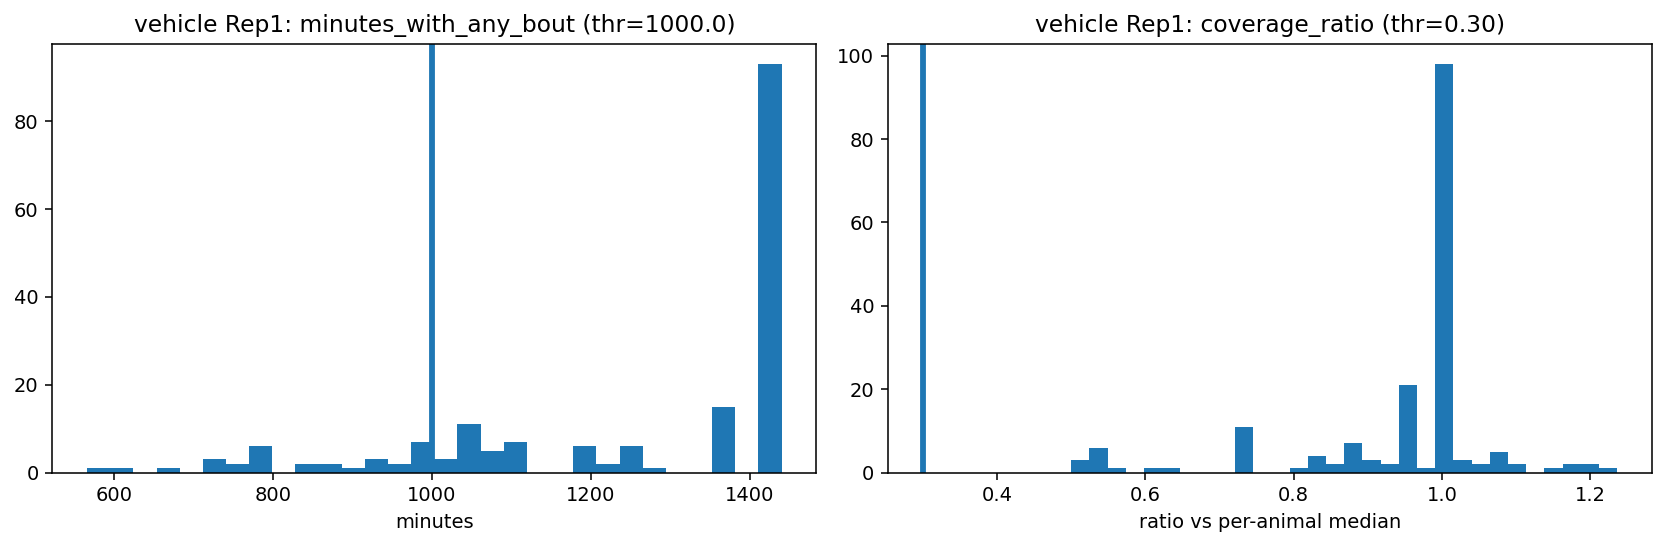

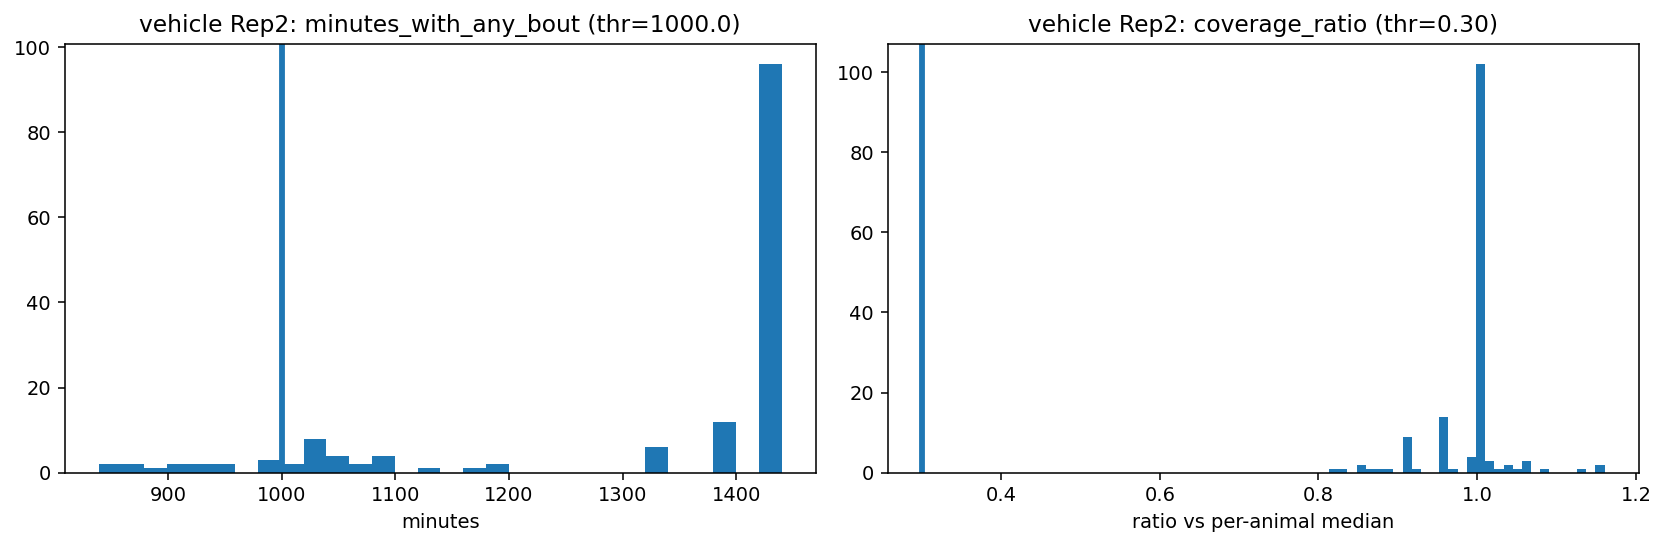

In [25]:

# Visualize coverage distributions + chosen thresholds (per group/rep)
for (group, rep), g in cov_df.groupby(["group","replicate"]):
    rule = qc_rules_df[(qc_rules_df["group"]==group) & (qc_rules_df["replicate"]==rep)].iloc[0]
    thr_m = rule["thr_minutes_any"]
    thr_r = rule["thr_ratio"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(g["minutes_with_any_bout"], bins=30)
    axes[0].axvline(thr_m, linewidth=3)
    axes[0].set_title(f"{group} {rep}: minutes_with_any_bout (thr={thr_m:.1f})")
    axes[0].set_xlabel("minutes")

    axes[1].hist(g["coverage_ratio"], bins=30)
    axes[1].axvline(thr_r, linewidth=3)
    axes[1].set_title(f"{group} {rep}: coverage_ratio (thr={thr_r:.2f})")
    axes[1].set_xlabel("ratio vs per-animal median")

    plt.tight_layout()
    plt.show()

---
## 5) Wavelet Features (Ultradian, Circadian, log(U/C))

We compute wavelet features from **locomotion-only** minute counts:
- `U_1_3h`: daily mean ultradian-band power (1–3h)
- `C_23_25h`: daily mean circadian-band power (23–25h)
- `log_U_over_C`: daily mean log ratio

Then we join:
- coverage metrics (`minutes_with_any_bout`, `coverage_ratio`)
- QC keep flag (based on auto thresholds)
- event indicators (`is_event`, `is_event_or_next`)

In [26]:

def compute_wavelet_power(signal_1min, periods_minutes=PERIODS_MINUTES, w=5):
    x = pd.Series(signal_1min).interpolate().bfill().ffill().fillna(0).values
    fs = 1
    scales = periods_minutes * fs * w / (2 * np.pi)
    coeffs = cwt(x, morlet2, scales, w=w)
    power = np.abs(coeffs) ** 2
    return power, periods_minutes

def extract_band_power_ts(power, periods_minutes, band_hours):
    periods_hours = periods_minutes / 60
    mask = (periods_hours >= band_hours[0]) & (periods_hours <= band_hours[1])
    if not np.any(mask):
        return np.zeros(power.shape[1])
    return np.max(power[mask, :], axis=0)

def daily_mean_from_minute_ts(minute_ts, n_days):
    out = []
    for day in range(1, n_days + 1):
        s = (day - 1) * MINUTES_PER_DAY
        e = day * MINUTES_PER_DAY
        out.append(np.nanmean(minute_ts[s:e]) if e <= len(minute_ts) else np.nan)
    return out

def robust_z(x, eps=1e-8):
    x = np.asarray(x, dtype=float)
    med = np.nanmedian(x)
    mad = np.nanmedian(np.abs(x - med))
    return (x - med) / (mad + eps)

print("Wavelet + z-score functions ready.")

Wavelet + z-score functions ready.


In [27]:
# Build wavelet daily features per mouse-day (valid days only) WITHOUT df_bouts
rows = []

# make sure these exist near the top:
# LOCO_COLS = ["animal_id","start_time","end_time","state_name"]

for group, reps in GROUPS.items():
    for rep, cfg in reps.items():
        vstart, vend = cfg["valid_days"]
        n_days = cfg["n_days"]

        # Event day sets
        event_days = {cfg["dose_1_day"], cfg["cage_change_day"], cfg["dose_2_day"]}
        event_and_next = set(event_days) | {d + 1 for d in event_days if (d + 1) <= n_days}

        start_date = pd.to_datetime(cfg["analysis_start"])
        date_list = [(start_date + pd.Timedelta(days=i)).date() for i in range(n_days)]

        for cage_id in cfg["cages"]:
            # Load locomotion only for this cage (memory-safe)
            df_loco = load_parquet_s3(
                conn,
                cage_id,
                cfg["analysis_start"],
                cfg["analysis_end"],
                "animal_bouts.parquet",
                columns=LOCO_COLS,
                where="state_name = 'animal_bouts.locomotion'"
            )
            if df_loco.empty:
                continue

            # For each animal in this cage
            for aid, a_loco in df_loco.groupby("animal_id", sort=False):
                a_loco = a_loco.copy()
                if a_loco.empty:
                    continue

                x_1min = bouts_to_minute_counts_calendar(
                    a_loco,
                    cfg["analysis_start"],
                    n_days,
                    anchor_hour=0,   # or 6 if you switch to behavior-day
                    binary=True
                )

                power, periods = compute_wavelet_power(x_1min, PERIODS_MINUTES, w=5)
                U_ts = extract_band_power_ts(power, periods, (1, 3))
                C_ts = extract_band_power_ts(power, periods, (23, 25))

                U_day = daily_mean_from_minute_ts(U_ts, n_days)
                C_day = daily_mean_from_minute_ts(C_ts, n_days)

                for day in range(vstart, vend + 1):
                    u = float(U_day[day - 1])
                    c = float(C_day[day - 1])
                    ratio = float(np.log((u + 1e-6) / (c + 1e-6)))

                    rows.append({
                        "group": group,
                        "replicate": rep,
                        "cage_id": int(cage_id),
                        "animal_id": int(aid),
                        "day": int(day),
                        "date": str(date_list[day - 1]),
                        "U_1_3h": u,
                        "C_23_25h": c,
                        "log_U_over_C": ratio,
                        "is_event": int(day in event_days),
                        "is_event_or_next": int(day in event_and_next),
                    })

feat = pd.DataFrame(rows)

# join coverage metrics (include cage_id if you created cov_df with cage_id; recommended)
merge_cols = ["group","replicate","animal_id","day","minutes_with_any_bout","coverage_ratio"]
if "cage_id" in cov_df.columns and "cage_id" in feat.columns:
    feat = feat.merge(cov_df[merge_cols + ["cage_id"]],
                      on=["group","replicate","cage_id","animal_id","day"],
                      how="left")
else:
    feat = feat.merge(cov_df[merge_cols],
                      on=["group","replicate","animal_id","day"],
                      how="left")

# apply QC keep flag
feat["qc_keep"] = False
for _, r in qc_rules_df.iterrows():
    m = (feat["group"]==r["group"]) & (feat["replicate"]==r["replicate"])
    feat.loc[m, "qc_keep"] = (
        (feat.loc[m, "minutes_with_any_bout"].fillna(0) >= r["thr_minutes_any"]) &
        (feat.loc[m, "coverage_ratio"].fillna(0) >= r["thr_ratio"])
    )

print("Feature rows:", len(feat))
print("QC keep rate by group/rep:")
print(feat.groupby(["group","replicate"])["qc_keep"].mean().round(3))
feat.head()

Feature rows: 252
QC keep rate by group/rep:
group    replicate
vehicle  Rep1         0.933
         Rep2         0.974
Name: qc_keep, dtype: float64


,group,replicate,cage_id,animal_id,day,date,U_1_3h,C_23_25h,log_U_over_C,is_event,is_event_or_next,minutes_with_any_bout,coverage_ratio,qc_keep
0,vehicle,Rep1,4918,9257,2,2025-01-08,6.644774,21.293436,-1.164568,0,0,1380.0,0.958333,True
1,vehicle,Rep1,4918,9257,3,2025-01-09,2.413432,38.240486,-2.762845,0,0,1440.0,1.000000,True
2,vehicle,Rep1,4918,9257,4,2025-01-10,4.371401,44.669961,-2.324218,0,0,1440.0,1.000000,True
3,vehicle,Rep1,4918,9257,5,2025-01-11,3.638568,48.926621,-2.598731,0,0,1440.0,1.000000,True
4,vehicle,Rep1,4918,9257,6,2025-01-12,5.904495,63.181696,-2.370301,0,0,1440.0,1.000000,True


---
## 6) Per-Replicate PCA + Gaussian Mixture + Confound + Monte Carlo

For each (group, replicate), we run:

### (A) Robust within-mouse normalization
Compute `z_U`, `z_C`, `z_log(U/C)` per animal **using QC-kept days only**.

### (B) PCA
Fit PCA on z-features and report:
- explained variance
- loadings

### (C) 2-component Gaussian mixture (GMM) on PCA space
Fit GMM on (PC1, PC2) and get `p_aberrant`.  
We define the “aberrant component” as the one with **lower mean z_U** (suppressed ultradian).

### (D) Handling confound enrichment
Compare `p_aberrant` on event±1 days vs normal days (Mann-Whitney U).

### (E) Monte Carlo cyclicity test (lag=4 days)
Compute mean autocorr@4 for `p_aberrant` per mouse, averaged across mice.  
Generate null distributions by **circularly shifting** each mouse’s series.  
Report a p-value-ish upper-tail probability `P(null ≥ observed)`.  
Repeat after removing event±1 days.

You can control Monte Carlo cost with `N_SIMS`.

In [28]:

# def autocorr_lag(x, lag=4):
#     x = np.asarray(x, dtype=float)
#     if len(x) <= lag:
#         return np.nan
#     x0, x1 = x[:-lag], x[lag:]
#     if np.nanstd(x0) < 1e-10 or np.nanstd(x1) < 1e-10:
#         return np.nan
#     return np.corrcoef(x0, x1)[0, 1]

def autocorr_lag(series_by_day, lag=4):
    """
    Calendar-based autocorrelation.
    series_by_day must be a pandas Series indexed by integer day.
    """
    s = series_by_day.sort_index()
    s_shift = s.shift(-lag)

    mask = s.notna() & s_shift.notna()
    if mask.sum() < 3:
        return np.nan

    x0 = s[mask].values.astype(float)
    x1 = s_shift[mask].values.astype(float)

    if np.nanstd(x0) < 1e-10 or np.nanstd(x1) < 1e-10:
        return np.nan

    return float(np.corrcoef(x0, x1)[0, 1])

# def circular_shift(arr, k):
#     arr = np.asarray(arr)
#     if len(arr) == 0:
#         return arr
#     k = k % len(arr)
#     return np.concatenate([arr[-k:], arr[:-k]]) if k != 0 else arr
def circular_shift(series_by_day, k):
    """
    Circular shift over the full calendar grid (preserves NaN structure).
    """
    s = series_by_day.sort_index()
    vals = s.values
    n = len(vals)
    if n == 0:
        return s

    k = int(k) % n
    if k == 0:
        return s

    shifted = np.concatenate([vals[-k:], vals[:-k]])
    return pd.Series(shifted, index=s.index)
# def cyclicity_score(df, prob_col="p_aberrant", lag=4):
#     vals = []
#     for aid, g in df.groupby("animal_id"):
#         g = g.sort_values("day")
#         vals.append(autocorr_lag(g[prob_col].values, lag=lag))
#     vals = np.asarray(vals, dtype=float)
#     return float(np.nanmean(vals)), vals

def cyclicity_score(df, prob_col="p_aberrant", lag=4):
    acs = []
    for aid, g in df.groupby("animal_id"):
        g = g.sort_values("day")
        dmin, dmax = int(g["day"].min()), int(g["day"].max())
        full_index = pd.Index(range(dmin, dmax + 1), name="day")

        s = g.set_index("day")[prob_col].sort_index()
        s = s[~s.index.duplicated(keep="last")]
        s = s.reindex(full_index)

        acs.append(autocorr_lag(s, lag=lag))

    acs = np.asarray(acs, dtype=float)
    return float(np.nanmean(acs)), acs

# def monte_carlo_null(df, prob_col="p_aberrant", lag=4, n_sims=500, seed=0):
#     rng = np.random.default_rng(seed)
#     null = []
#     for _ in range(n_sims):
#         parts = []
#         for aid, g in df.groupby("animal_id"):
#             g = g.sort_values("day").copy()
#             s = g[prob_col].values
#             k = rng.integers(0, len(s)) if len(s) > 0 else 0
#             g["_shift"] = circular_shift(s, k)
#             parts.append(g)
#         tmp = pd.concat(parts, ignore_index=True)
#         # compute mean ac@lag over mice
#         acs = []
#         for aid, g2 in tmp.groupby("animal_id"):
#             g2 = g2.sort_values("day")
#             acs.append(autocorr_lag(g2["_shift"].values, lag=lag))
#         null.append(float(np.nanmean(acs)))
#     return np.asarray(null, dtype=float)
def monte_carlo_null(df, prob_col="p_aberrant", lag=4, n_sims=500, seed=0):
    rng = np.random.default_rng(seed)

    grids = {}
    lengths = {}
    for aid, g in df.groupby("animal_id"):
        g = g.sort_values("day")
        dmin, dmax = int(g["day"].min()), int(g["day"].max())
        idx = pd.Index(range(dmin, dmax + 1), name="day")

        s = g.set_index("day")[prob_col].sort_index()
        s = s[~s.index.duplicated(keep="last")]
        s = s.reindex(idx)

        grids[aid] = s
        lengths[aid] = len(idx)

    null = np.empty(n_sims, dtype=float)
    for i in range(n_sims):
        acs = []
        for aid, s in grids.items():
            k = rng.integers(0, lengths[aid])
            acs.append(autocorr_lag(circular_shift(s, k), lag=lag))
        null[i] = np.nanmean(acs)

    return null
print("Monte Carlo helpers ready.")

Monte Carlo helpers ready.


In [39]:
def run_full_analysis(feat_all, group, rep, n_sims=500, lag=4, show_plots=True):
    """
    Full per-(group,rep) pipeline:
      - robust within-mouse z-features (QC-kept days only)
      - PCA on z-features (VISUALIZATION ONLY)
      - 2-comp GMM on estrus-relevant space (z_U, z_log(U/C)) -> p_aberrant
      - confound enrichment (event±1 vs normal)
      - Monte Carlo cyclicity test at lag=4 (with + without event±1)
      - safe plotting for NaN/null edge cases
    """

    # ----------------------------
    # Subset to this group/rep + QC-kept days
    # ----------------------------
    sub = feat_all[
        (feat_all["group"] == group) &
        (feat_all["replicate"] == rep) &
        (feat_all["qc_keep"])
    ].copy()

    if len(sub) < 10:
        raise ValueError(f"{group} {rep}: Too few rows after QC_keep (n={len(sub)}).")

    # ----------------------------
    # Robust z per animal (on retained days)
    # ----------------------------
    sub["z_U_1_3h"] = sub.groupby("animal_id")["U_1_3h"].transform(lambda s: robust_z(s.values))
    sub["z_C_23_25h"] = sub.groupby("animal_id")["C_23_25h"].transform(lambda s: robust_z(s.values))
    sub["z_log_U_over_C"] = sub.groupby("animal_id")["log_U_over_C"].transform(lambda s: robust_z(s.values))

    Z = ["z_U_1_3h", "z_C_23_25h", "z_log_U_over_C"]
    sub = sub.dropna(subset=Z).copy()

    if len(sub) < 10:
        raise ValueError(f"{group} {rep}: Too few non-NaN rows after z-feature dropna (n={len(sub)}).")

    # ----------------------------
    # PCA (visualization space)
    # ----------------------------
    pca = PCA(n_components=2, random_state=0)
    PC = pca.fit_transform(sub[Z].values)
    sub["PC1"], sub["PC2"] = PC[:, 0], PC[:, 1]

    evr = pca.explained_variance_ratio_
    loadings = pd.DataFrame(pca.components_.T, index=Z, columns=["PC1", "PC2"])

    # ----------------------------
    # GMM for p_aberrant (FIT ON ESTRUS-RELEVANT FEATURES, NOT PCs)
    # ----------------------------
    Xg = sub[["z_U_1_3h", "z_log_U_over_C"]].values

    gmm = GaussianMixture(
        n_components=2,
        covariance_type="full",
        reg_covar=1e-6,
        random_state=0
    )
    gmm.fit(Xg)
    post = gmm.predict_proba(Xg)
    hard = gmm.predict(Xg)
    weights = gmm.weights_

    # aberrant = component with LOWER mean z_U (suppressed ultradian)
    mean_zU_by_comp = [sub.loc[hard == k, "z_U_1_3h"].mean() for k in [0, 1]]
    aberr_comp = int(np.argmin(mean_zU_by_comp))
    sub["p_aberrant"] = post[:, aberr_comp]

    # ----------------------------
    # Confound enrichment: event±1 vs normal
    # ----------------------------
    ev = sub.loc[sub["is_event_or_next"] == 1, "p_aberrant"].values
    ne = sub.loc[sub["is_event_or_next"] == 0, "p_aberrant"].values

    if len(ev) > 0 and len(ne) > 0 and np.isfinite(ev).any() and np.isfinite(ne).any():
        p_mwu = float(mannwhitneyu(ev, ne, alternative="greater").pvalue)
        mean_ev, mean_ne = float(np.nanmean(ev)), float(np.nanmean(ne))
    else:
        p_mwu, mean_ev, mean_ne = np.nan, np.nan, np.nan

    # ----------------------------
    # Monte Carlo cyclicity (all days)
    # ----------------------------
    obs_ac, _ = cyclicity_score(sub, prob_col="p_aberrant", lag=lag)
    null = monte_carlo_null(sub, prob_col="p_aberrant", lag=lag, n_sims=n_sims, seed=0)
    null_f = null[np.isfinite(null)]
    p_mc = float((np.sum(null_f >= obs_ac) + 1) / (len(null_f) + 1)) if len(null_f) > 0 else np.nan

    # ----------------------------
    # Monte Carlo cyclicity (no event±1)
    # ----------------------------
    # --- no-events: KEEP GRID, MASK VALUES ---
    sub_noevt = sub.copy()
    sub_noevt.loc[sub_noevt["is_event"] == 1, "p_aberrant"] = np.nan
    
    obs_ac_noevt, _ = cyclicity_score(sub_noevt, prob_col="p_aberrant", lag=lag)
    
    null_noevt = monte_carlo_null(sub_noevt, prob_col="p_aberrant", lag=lag, n_sims=n_sims, seed=1)
    null_noevt_f = null_noevt[np.isfinite(null_noevt)]
    
    if np.isfinite(obs_ac_noevt) and len(null_noevt_f) > 0:
        p_mc_noevt = float((np.sum(null_noevt_f >= obs_ac_noevt) + 1) / (len(null_noevt_f) + 1))
    else:
        p_mc_noevt = np.nan

    # ----------------------------
    # Outliers in PCA space (for QC/debug)
    # ----------------------------
    sub["pc_r2"] = sub["PC1"] ** 2 + sub["PC2"] ** 2
    outliers = sub.sort_values("pc_r2", ascending=False).head(8)[
        ["group", "replicate", "cage_id", "animal_id", "day", "date", "PC1", "PC2",
         "U_1_3h", "C_23_25h", "log_U_over_C",
         "z_U_1_3h", "z_C_23_25h", "z_log_U_over_C",
         "minutes_with_any_bout", "coverage_ratio", "is_event_or_next", "p_aberrant"]
    ]

    # ----------------------------
    # Plots (optional)
    # ----------------------------
    if show_plots:
        # PCA colored by event±1
        plt.figure(figsize=(7, 5))
        m = sub["is_event_or_next"].astype(bool)
        plt.scatter(sub.loc[~m, "PC1"], sub.loc[~m, "PC2"], alpha=0.55, s=18, label="normal")
        plt.scatter(sub.loc[m, "PC1"], sub.loc[m, "PC2"], alpha=0.85, s=20, label="event±1")
        plt.xlabel("PC1"); plt.ylabel("PC2")
        plt.title(f"{group} {rep}: PCA after auto-QC (n={len(sub)})")
        plt.legend(); plt.tight_layout(); plt.show()

        # PCA colored by p_aberrant
        plt.figure(figsize=(7, 5))
        sc = plt.scatter(sub["PC1"], sub["PC2"], c=sub["p_aberrant"], s=18, alpha=0.85)
        plt.xlabel("PC1"); plt.ylabel("PC2")
        plt.title(f"{group} {rep}: PCA colored by p_aberrant (GMM on z_U + z_log(U/C))")
        plt.colorbar(sc, label="p_aberrant"); plt.tight_layout(); plt.show()

        # Monte Carlo hist (all days)
        if len(null_f) > 0:
            plt.figure(figsize=(7, 4))
            plt.hist(null_f, bins=30)
            if np.isfinite(obs_ac):
                plt.axvline(obs_ac, linewidth=3)
            plt.xlabel(f"mean autocorr@{lag} (null)"); plt.ylabel("count")
            plt.title(f"{group} {rep}: Monte Carlo (p≈{p_mc:.3g})")
            plt.tight_layout(); plt.show()

        # Monte Carlo hist (no events)
        if len(null_noevt_f) > 0:
            plt.figure(figsize=(7, 4))
            plt.hist(null_noevt_f, bins=30)
            if np.isfinite(obs_ac_noevt):
                plt.axvline(obs_ac_noevt, linewidth=3)
            plt.xlabel(f"mean autocorr@{lag} (null, no events)"); plt.ylabel("count")
            plt.title(f"{group} {rep}: Monte Carlo no-events (p≈{p_mc_noevt:.3g})")
            plt.tight_layout(); plt.show()
        else:
            print(f"{group} {rep}: Skipping no-events histogram (null_noevt all NaN / insufficient data)")

        print(f"{group} {rep}: GMM weights={weights}, aberr_comp={aberr_comp}, mean_zU_by_comp={mean_zU_by_comp}")
        print(f"{group} {rep}: p_aberrant >0.9 frac={(sub['p_aberrant']>0.9).mean():.3f}, <0.1 frac={(sub['p_aberrant']<0.1).mean():.3f}")

    summary = {
        "group": group,
        "replicate": rep,
        "n_rows_qc": int(len(sub)),
        "evr_pc1": float(evr[0]),
        "evr_pc2": float(evr[1]),
        "evr_cum": float(np.sum(evr)),
        "loadings": loadings.round(4).to_string(),

        "gmm_weights_comp0": float(weights[0]),
        "gmm_weights_comp1": float(weights[1]),
        "gmm_mean_zU_comp0": float(mean_zU_by_comp[0]),
        "gmm_mean_zU_comp1": float(mean_zU_by_comp[1]),
        "aberr_comp": int(aberr_comp),

        "mean_p_aberrant_event±1": mean_ev,
        "mean_p_aberrant_normal": mean_ne,
        "mwu_p_event_greater": p_mwu,

        "obs_mean_autocorr@4": float(obs_ac),
        "mc_pvalue": p_mc,

        "obs_mean_autocorr@4_noevents": float(obs_ac_noevt),
        "mc_pvalue_noevents": p_mc_noevt,
    }

    return sub, summary, outliers, gmm, hard

---
## 7) Run the Full Pipeline (per group × replicate)

Tune these:
- `N_SIMS`: Monte Carlo simulations (start at 200–500; increase for final figures)
- `SHOW_PLOTS`: True/False

Outputs:
- `summary_df`: one row per (group,rep)
- `outliers_df`: outlier mouse-days across runs

In [40]:
SHOW_PLOTS = True   # or False if you want it fast + quiet

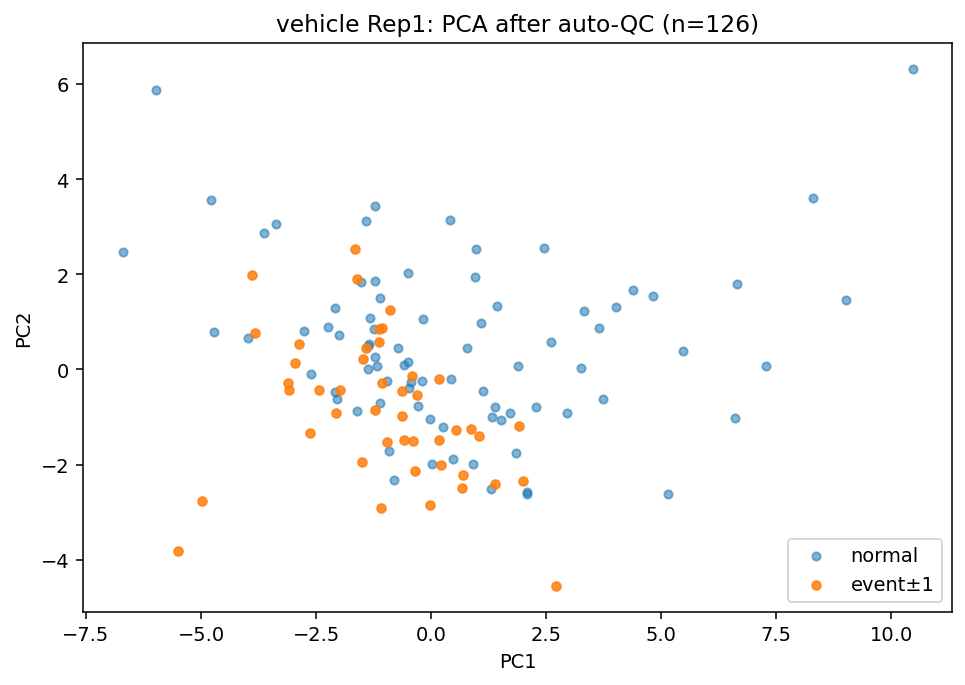

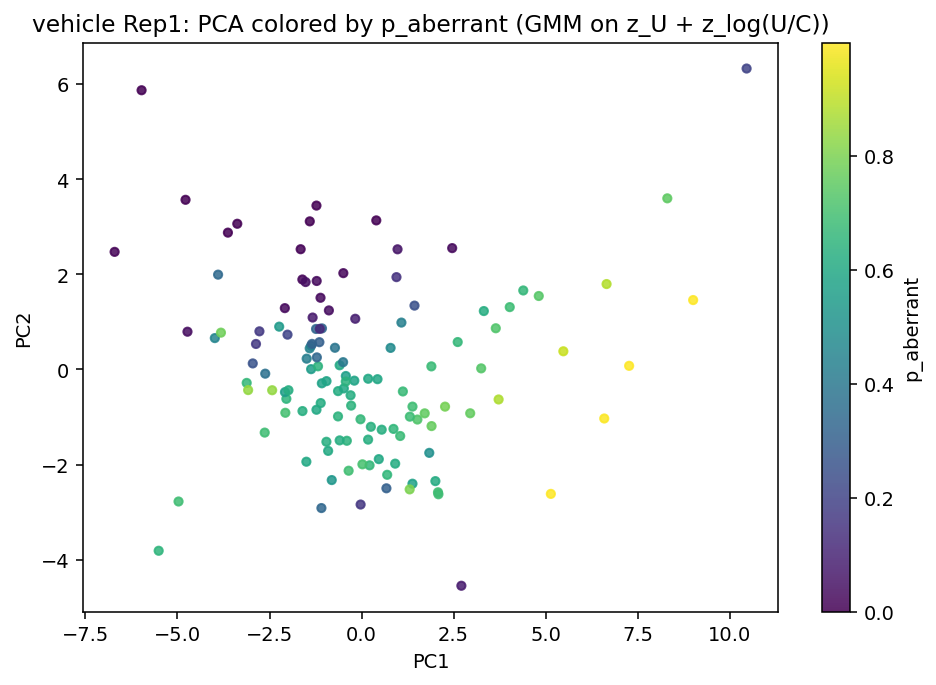

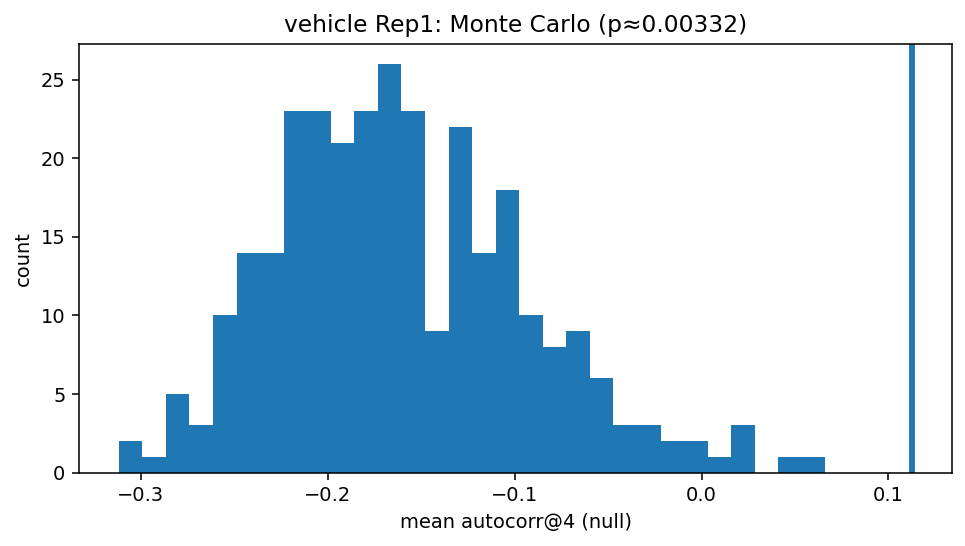

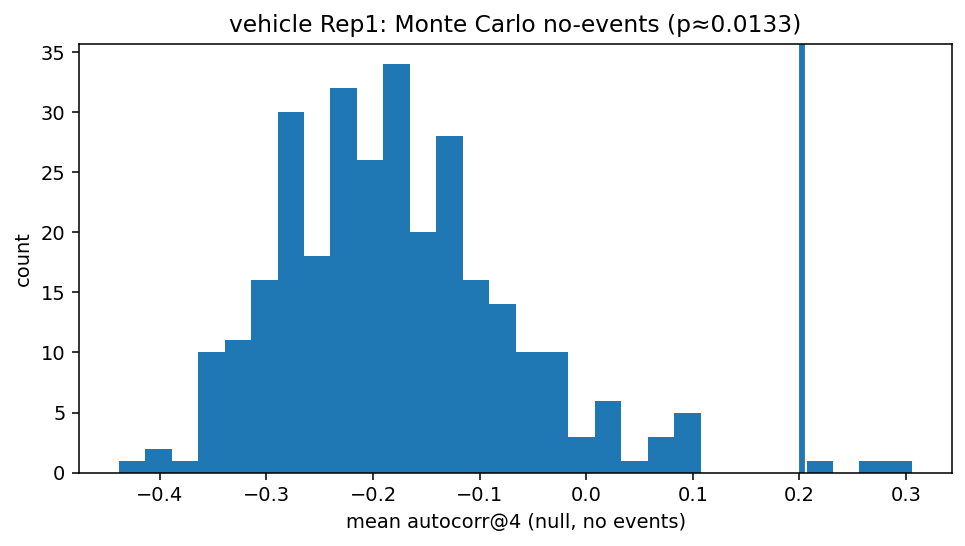

vehicle Rep1: GMM weights=[0.49232371 0.50767629], aberr_comp=0, mean_zU_by_comp=[-0.5862916448082184, 1.4481383737187175]
vehicle Rep1: p_aberrant >0.9 frac=0.040, <0.1 frac=0.175


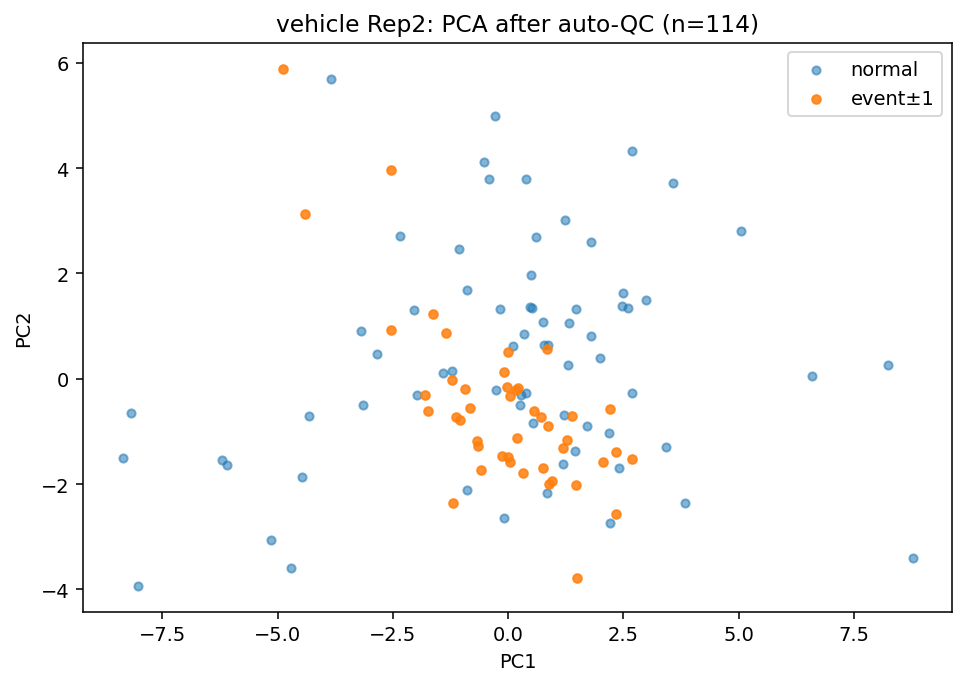

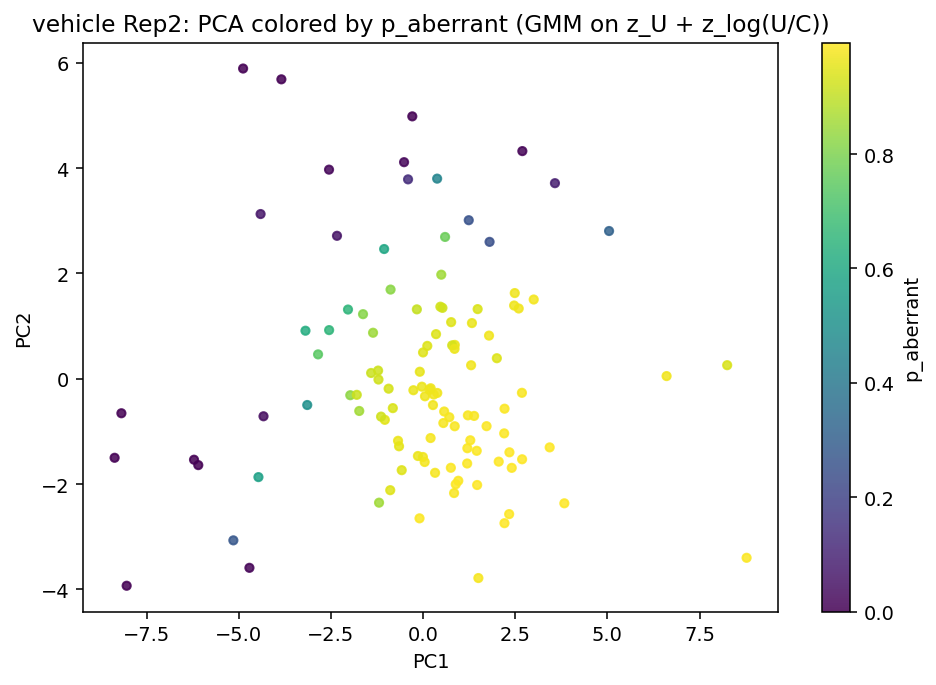

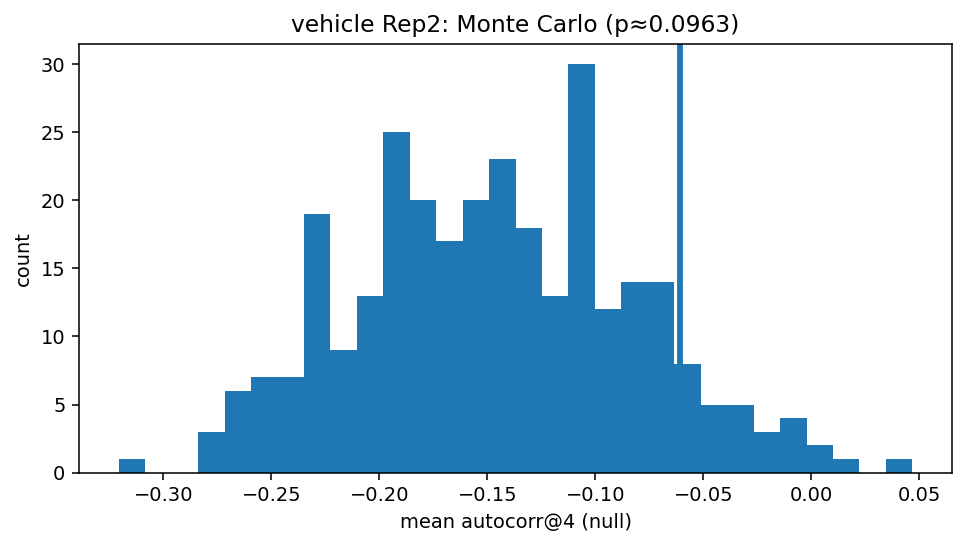

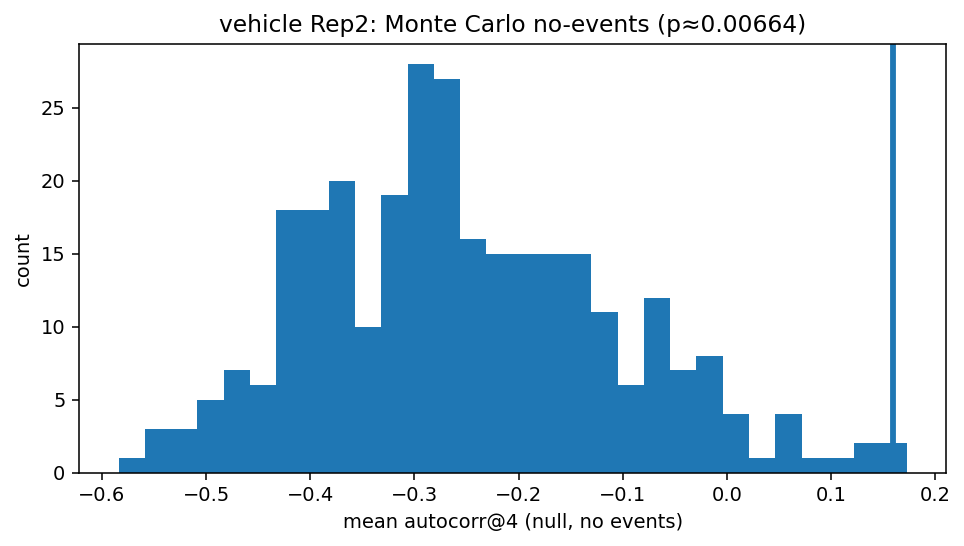

vehicle Rep2: GMM weights=[0.23251636 0.76748364], aberr_comp=1, mean_zU_by_comp=[2.1197568724582965, -0.3190483599346399]
vehicle Rep2: p_aberrant >0.9 frac=0.675, <0.1 frac=0.140


,group,replicate,n_rows_qc,evr_pc1,evr_pc2,evr_cum,loadings,gmm_weights_comp0,gmm_weights_comp1,gmm_mean_zU_comp0,gmm_mean_zU_comp1,aberr_comp,mean_p_aberrant_event±1,mean_p_aberrant_normal,mwu_p_event_greater,obs_mean_autocorr@4,mc_pvalue,obs_mean_autocorr@4_noevents,mc_pvalue_noevents
0,vehicle,Rep1,126,0.704246,0.275164,0.979410,PC1 PC2\nz_U_1_3h ...,0.492324,0.507676,-0.586292,1.448138,0,0.511331,0.477026,0.317927,0.112764,0.003322,0.202026,0.013289
1,vehicle,Rep2,114,0.627390,0.319018,0.946408,PC1 PC2\nz_U_1_3h ...,0.232516,0.767484,2.119757,-0.319048,1,0.888988,0.687190,0.001708,-0.060890,0.096346,0.159779,0.006645


In [41]:
N_SIMS = 300
LAG = 4

summaries = []
outlier_tables = []
results_by_run = {}

for group in GROUPS.keys():
    for rep in ["Rep1","Rep2"]:
        sub, summary, outliers, gmm, hard = run_full_analysis(
            feat, group, rep, n_sims=N_SIMS, lag=LAG, show_plots=SHOW_PLOTS
        )
        summaries.append(summary)
        outlier_tables.append(outliers.assign(run=f"{group}|{rep}"))
        results_by_run[(group,rep)] = {
            "sub": sub,
            "gmm": gmm,
            "hard": hard
        }

summary_df = pd.DataFrame(summaries)
outliers_df = pd.concat(outlier_tables, ignore_index=True)

summary_df

---
## 8) Final Copy-Paste Summary Cell

This cell prints:
- Auto-QC thresholds per (group,rep) + how they were chosen
- Final pipeline summary table (PCA + GMM + confound + Monte Carlo)
- Outliers table

It also saves CSVs:
- `auto_qc_rules.csv`
- `wavelet_pipeline_summary.csv`
- `wavelet_pipeline_outliers.csv`

In [42]:

# =============================================================================
# FINAL SUMMARY (copy/paste friendly)
# =============================================================================
print("="*110)
print("AUTO-QC RULES (per group/rep)")
print("="*110)
qc_display = qc_rules_df.copy()
qc_display["info_minutes"] = qc_display["info_minutes"].apply(lambda d: str(d))
qc_display["info_ratio"] = qc_display["info_ratio"].apply(lambda d: str(d))
print(qc_display[["group","replicate","thr_minutes_any","thr_ratio","info_minutes","info_ratio","n_rows"]].to_string(index=False))

print("\n" + "="*110)
print("PIPELINE SUMMARY (per group/rep)")
print("="*110)
cols = [
    "group","replicate","n_rows_qc",
    "evr_pc1","evr_pc2","evr_cum",
    "aberr_comp",
    "mean_p_aberrant_event±1","mean_p_aberrant_normal","mwu_p_event_greater",
    "obs_mean_autocorr@4","mc_pvalue",
    "obs_mean_autocorr@4_noevents","mc_pvalue_noevents"
]
print(summary_df[cols].round(4).to_string(index=False))

print("\n" + "="*110)
print("PCA LOADINGS (per group/rep)")
print("="*110)
for _, row in summary_df.iterrows():
    print("\n" + "-"*110)
    print(f"{row['group']} {row['replicate']}  |  EVR: [{row['evr_pc1']:.4f}, {row['evr_pc2']:.4f}] (cum={row['evr_cum']:.4f})")
    print(row["loadings"])

print("\n" + "="*110)
print("TOP OUTLIERS (per run)")
print("="*110)
print(outliers_df.to_string(index=False))

# Save CSVs
qc_rules_df.to_csv("auto_qc_rules.csv", index=False)
summary_df.to_csv("wavelet_pipeline_summary.csv", index=False)
outliers_df.to_csv("wavelet_pipeline_outliers.csv", index=False)

print("\nSaved: auto_qc_rules.csv, wavelet_pipeline_summary.csv, wavelet_pipeline_outliers.csv")

AUTO-QC RULES (per group/rep)
  group replicate  thr_minutes_any  thr_ratio                                                                                                                                                      info_minutes                                         info_ratio  n_rows
vehicle      Rep1           1000.0        0.3  {'bic1': -29.06333494806083, 'bic2': -854.8223931251274, 'bic_delta': 825.7590581770665, 'n': 180, 'method': 'gmm2', 'low_comp': 1, 'thr_log': 7.26935979643065} {'method': 'fixed_conservative', 'thr_ratio': 0.3}     180
vehicle      Rep2           1000.0        0.3 {'bic1': -123.05204059930361, 'bic2': -957.2710941629356, 'bic_delta': 834.219053563632, 'n': 152, 'method': 'gmm2', 'low_comp': 1, 'thr_log': 7.269042890865739} {'method': 'fixed_conservative', 'thr_ratio': 0.3}     152

PIPELINE SUMMARY (per group/rep)
  group replicate  n_rows_qc  evr_pc1  evr_pc2  evr_cum  aberr_comp  mean_p_aberrant_event±1  mean_p_aberrant_normal  mwu_p_event_great

In [43]:
run = ("vehicle","Rep1")
gmm = results_by_run[run]["gmm"]
sub = results_by_run[run]["sub"]
hard = results_by_run[run]["hard"]

In [44]:
# Diagnose GMM components
weights = gmm.weights_
print("GMM weights:", weights)

for k in [0, 1]:
    idx = (hard == k)
    print(f"\nComponent {k}: n={idx.sum()}  weight≈{weights[k]:.3f}")
    print("  mean z_U:", sub.loc[idx, "z_U_1_3h"].mean())
    print("  mean z_C:", sub.loc[idx, "z_C_23_25h"].mean())
    print("  mean z_log(U/C):", sub.loc[idx, "z_log_U_over_C"].mean())

# How binary are the posteriors?
print("\nPosterior summary (current p_aberrant):")
print(sub["p_aberrant"].describe())
print("Fraction > 0.9:", (sub["p_aberrant"] > 0.9).mean())
print("Fraction < 0.1:", (sub["p_aberrant"] < 0.1).mean())

GMM weights: [0.49232371 0.50767629]

Component 0: n=77  weight≈0.492
  mean z_U: -0.5862916448082184
  mean z_C: 0.7136219743295764
  mean z_log(U/C): -0.695345020818277

Component 1: n=49  weight≈0.508
  mean z_U: 1.4481383737187175
  mean z_C: 0.08694721206680678
  mean z_log(U/C): 0.8674317693876277

Posterior summary (current p_aberrant):
count    1.260000e+02
mean     4.892775e-01
std      2.781166e-01
min      7.753046e-11
25%      3.022079e-01
50%      5.982950e-01
75%      6.759088e-01
max      9.980293e-01
Name: p_aberrant, dtype: float64
Fraction > 0.9: 0.03968253968253968
Fraction < 0.1: 0.1746031746031746


In [45]:
print("GMM weights:", gmm.weights_)
print("mean z_U by comp:", [sub.loc[hard==k, "z_U_1_3h"].mean() for k in [0,1]])

GMM weights: [0.49232371 0.50767629]
mean z_U by comp: [-0.5862916448082184, 1.4481383737187175]


In [46]:
for (group, rep), g in cov_df.groupby(["group","replicate"]):
    print("\n", group, rep)
    print(g["minutes_with_any_bout"].describe(percentiles=[0.01,0.05,0.1,0.5,0.9,0.95,0.99]).round(1))


 vehicle Rep1
count     180.0
mean     1260.5
std       237.8
min       566.0
1%        651.7
5%        780.0
10%       891.5
50%      1439.0
90%      1440.0
95%      1440.0
99%      1440.0
max      1440.0
Name: minutes_with_any_bout, dtype: float64

 vehicle Rep2
count     152.0
mean     1324.4
std       186.1
min       839.0
1%        865.7
5%        937.2
10%      1019.2
50%      1440.0
90%      1440.0
95%      1440.0
99%      1440.0
max      1440.0
Name: minutes_with_any_bout, dtype: float64


In [47]:
sub.assign(d= sub.sort_values(["animal_id","day"])
           .groupby("animal_id")["day"].diff()
          ).d.value_counts(dropna=False).sort_index()

d
1.0    117
NaN      9
Name: count, dtype: int64